# What changes when we include ineligible FOVs?

In [1]:
import os
import sys
from dataclasses import replace

sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules/scripts")]
import complex_investigation as ci
import complex_investigation_vis as vis
import complex_hypotheses as hypotheses
from IPython.display import display

In [2]:
CONFIG = ci.Config(
    max_items=4, support=0.01, expected_support=0.01, confidence=0.5,
    min_fovs=5, min_patients=3, min_group_fovs=10,
    visible_gap=0.15, top_n=8, permutations=4999,
    score=os.environ.get("SCORE_COLUMN", "Clinical score"),
)
PREFIX = "denominators_" + ("clin" if CONFIG.score.startswith("Clinical") else "path")

The displayed table is the baseline automatic screen with up to four cell types. Each denominator panel keeps the same rule-bearing numerator and compares all FOVs with eligible FOVs; it does not select more rules.

In [3]:
cells, metadata, rules = ci.load(CONFIG)
analysis = ci.analyse(rules, cells, metadata, CONFIG)
SPECS = ci.candidates(analysis['counts'], analysis['tests'], CONFIG)
display(SPECS)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
{'max_items': 4, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None, 'avoidance_min_

,organ,rule,kind,gap,contrast,patient_fdr,hits,patients,eligible,share,stream
0,Colon,Goblet -> CD4T + Neuron,avoids,0.800000,Control–Mild,0.568206,21,10,56,0.375000,visible
1,Colon,Goblet -> CD4T + Mast,avoids,0.726708,Control–Severe,0.701731,16,5,41,0.390244,visible
2,Colon,Goblet + Macrophage -> Epithelial + Plasma,attracts,0.520000,Control–Mild,0.416445,17,7,68,0.250000,visible
3,Colon,Fibroblast + Goblet -> Plasma,attracts,0.520000,Control–Mild,0.414641,15,6,68,0.220588,visible
4,Duodenum,Goblet -> Fibroblast + Neuron,avoids,0.496787,Control–Mild,0.341600,55,29,136,0.404412,visible
5,Duodenum,Muscle -> CD8T + SMV,avoids,0.466184,Control–Severe,0.404665,24,16,93,0.258065,visible
6,Duodenum,CD4T + Goblet -> Plasma,attracts,0.333938,Control–Mild,0.462809,8,6,51,0.156863,visible
7,Duodenum,Fibroblast + Paneth -> Epithelial + Neuron,attracts,0.326437,Mild–Severe,0.650191,21,14,81,0.259259,visible


In [4]:
def show_selected(index):
    vis.show_denominators(index, SPECS, analysis, metadata, PREFIX)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Colon_27d4dd0bba_summary.pdf


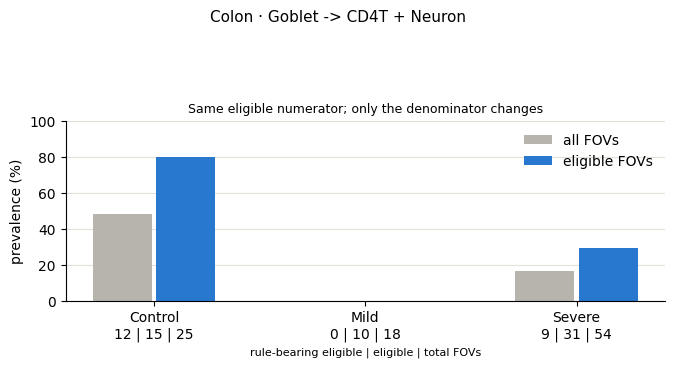

In [5]:
show_selected(0)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Colon_5b192fb9d1_summary.pdf


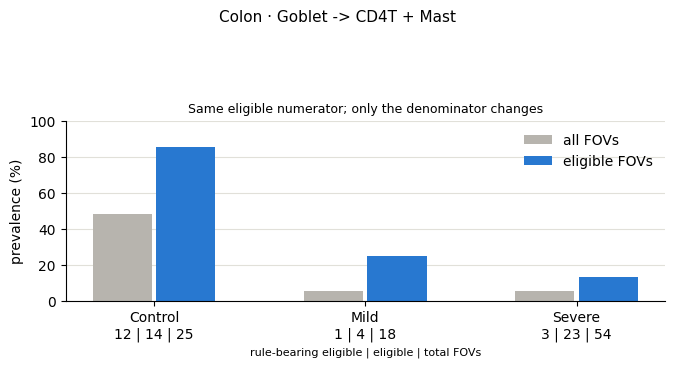

In [6]:
show_selected(1)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Colon_354784b70c_summary.pdf


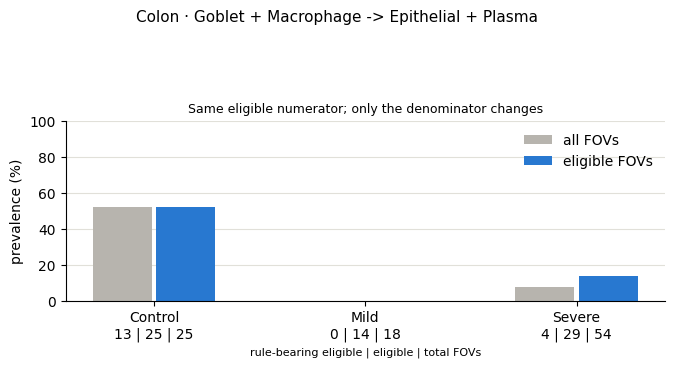

In [7]:
show_selected(2)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Colon_cae6b5640c_summary.pdf


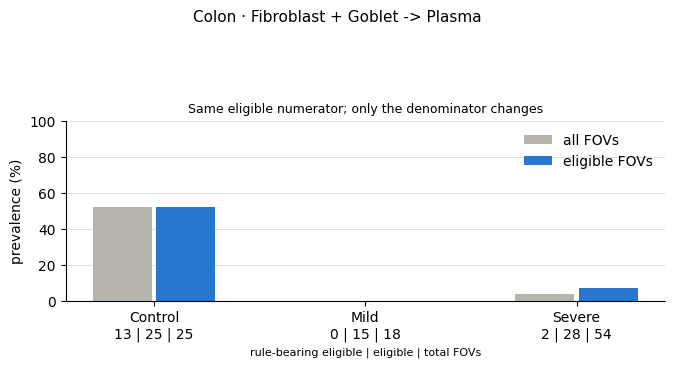

In [8]:
show_selected(3)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Duodenum_bdf167def3_summary.pdf


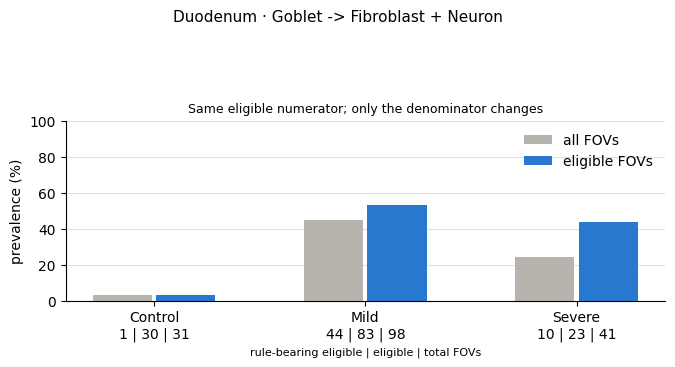

In [9]:
show_selected(4)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Duodenum_5f4b0da602_summary.pdf


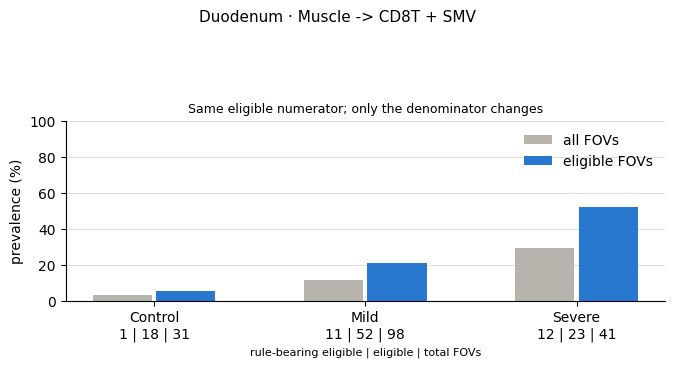

In [10]:
show_selected(5)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Duodenum_b52effceb2_summary.pdf


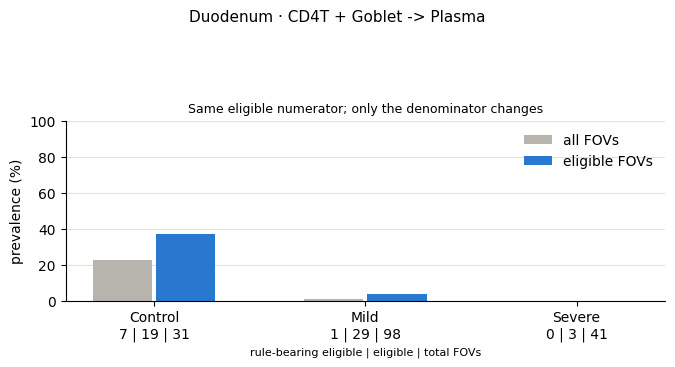

In [11]:
show_selected(6)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\denominators_clin_Duodenum_ec81592ecb_summary.pdf


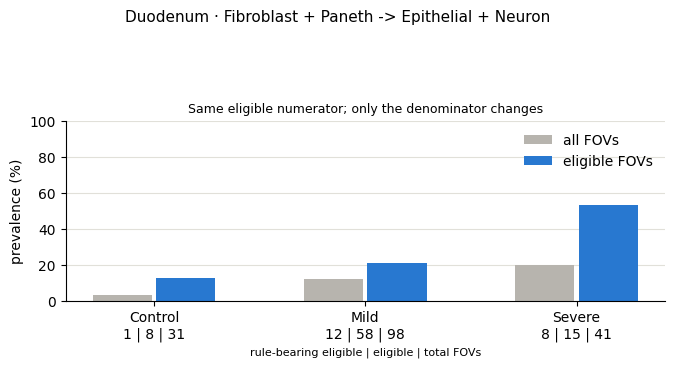

In [12]:
show_selected(7)

In [13]:
show_selected(8)

No denominator comparison at this index.


In [14]:
show_selected(9)

No denominator comparison at this index.


In [15]:
show_selected(10)

No denominator comparison at this index.


In [16]:
show_selected(11)

No denominator comparison at this index.


## Report view of the leading four-cell candidate

The first rule in the automatic baseline table above is shown with its measured shorter rule and representative full fields.

**[0] Colon · Goblet -> CD4T + Neuron**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,56,97,0,18
1,All,avoids,21,56,97,10,18
2,Control,attracts,0,15,25,0,4
3,Control,avoids,12,15,25,4,4
4,Mild,attracts,0,10,18,0,4
5,Mild,avoids,0,10,18,0,4
6,Severe,attracts,0,31,54,0,10
7,Severe,avoids,9,31,54,6,10


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_27d4dd0bba_parent_vs_complex.pdf


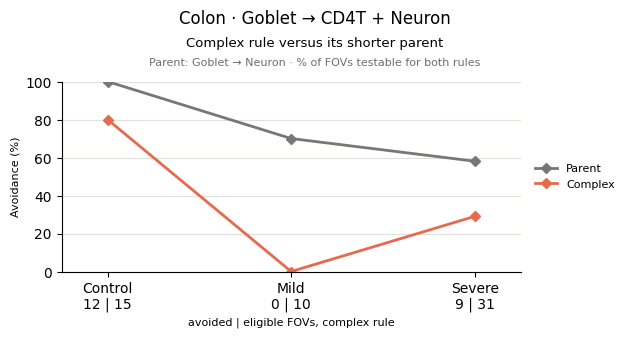

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_27d4dd0bba_summary.pdf


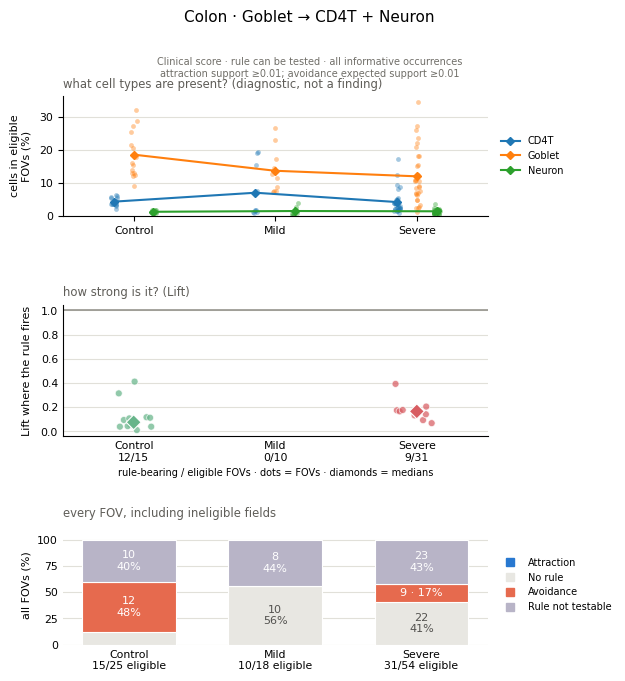

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_27d4dd0bba_parents.pdf


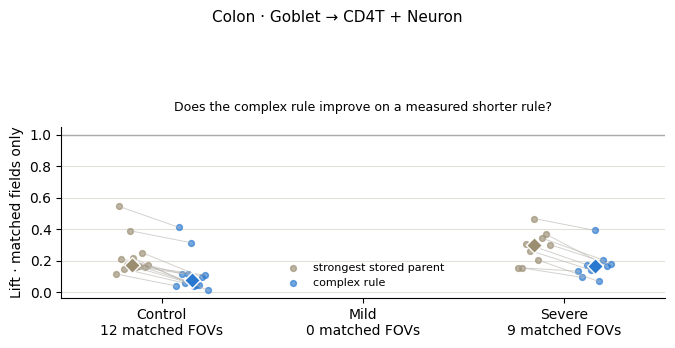

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,12,0.075496,0.171356,12
Severe,9,0.165766,0.301328,9


Read results_CN_pairwise.csv + results_CN_complex.csv
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_27d4dd0bba_fovs_avoidance_control.pdf


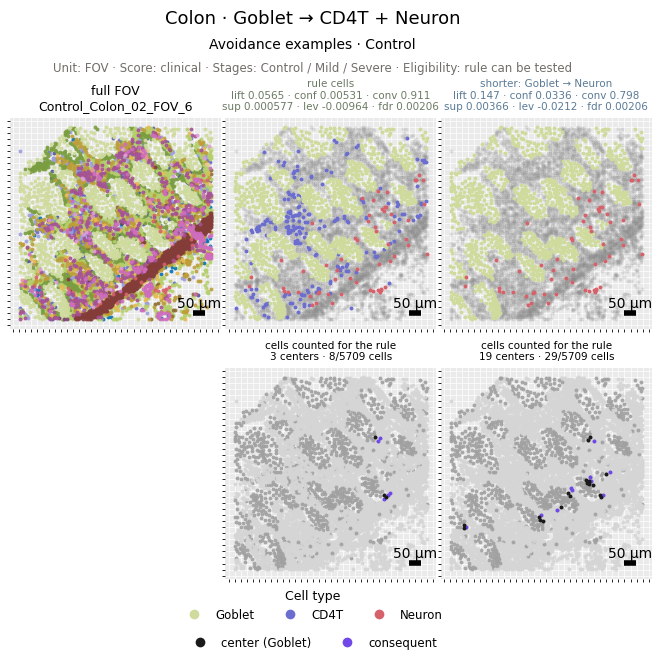

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_27d4dd0bba_fovs_avoidance_severe.pdf


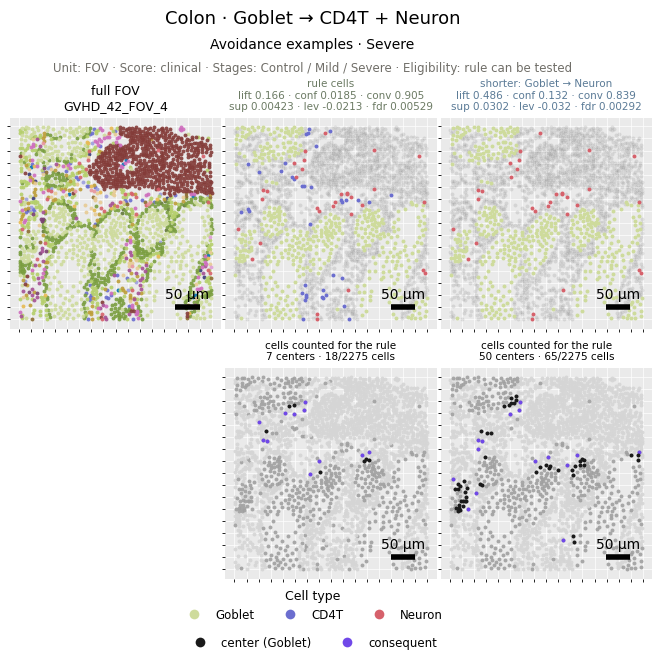

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_27d4dd0bba_fovs_no_rule.pdf


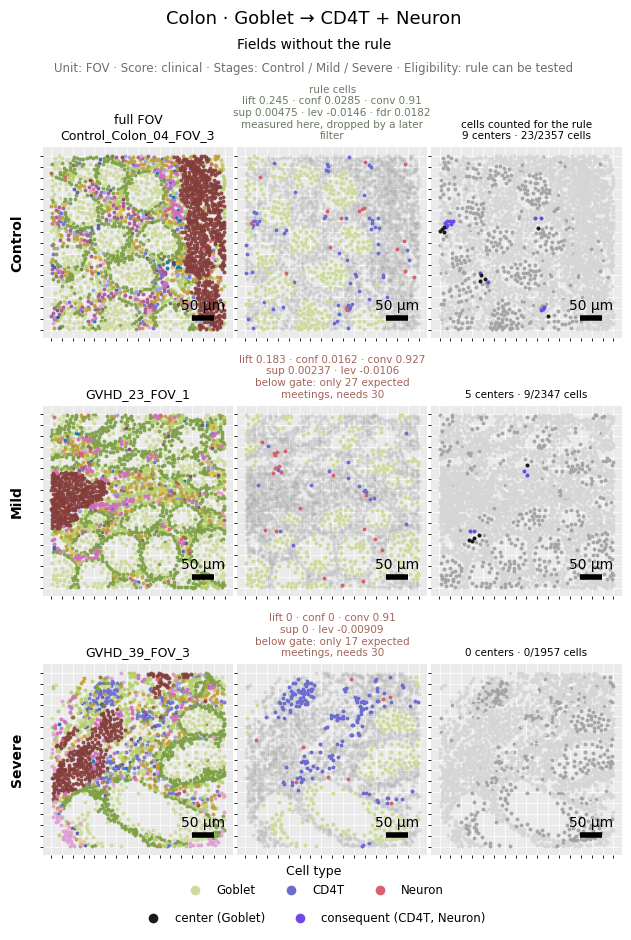

In [17]:
ci.save_tables(analysis, SPECS, "staging_clin")
vis.show_selected(0, SPECS, analysis, rules, cells, metadata, "staging_clin", parents=True)

## Report view of the duodenal goblet candidate

The baseline automatic screen places this rule at index 3. Show its full stage summary, measured shorter rule, and representative fields before deciding whether it belongs in the catalogue.

**[3] Colon · Fibroblast + Goblet -> Plasma**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,15,68,97,6,19
1,All,avoids,0,68,97,0,19
2,Control,attracts,13,25,25,4,4
3,Control,avoids,0,25,25,0,4
4,Mild,attracts,0,15,18,0,4
5,Mild,avoids,0,15,18,0,4
6,Severe,attracts,2,28,54,2,11
7,Severe,avoids,0,28,54,0,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_cae6b5640c_parent_vs_complex.pdf


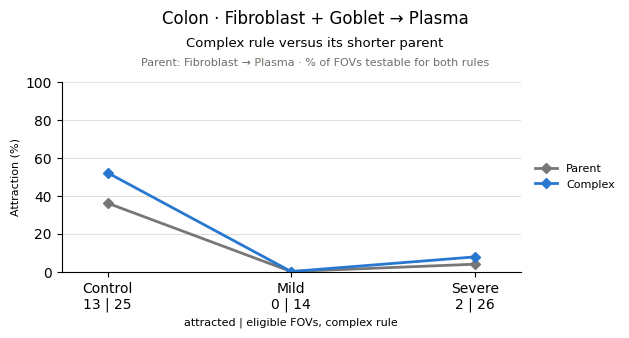

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_cae6b5640c_summary.pdf


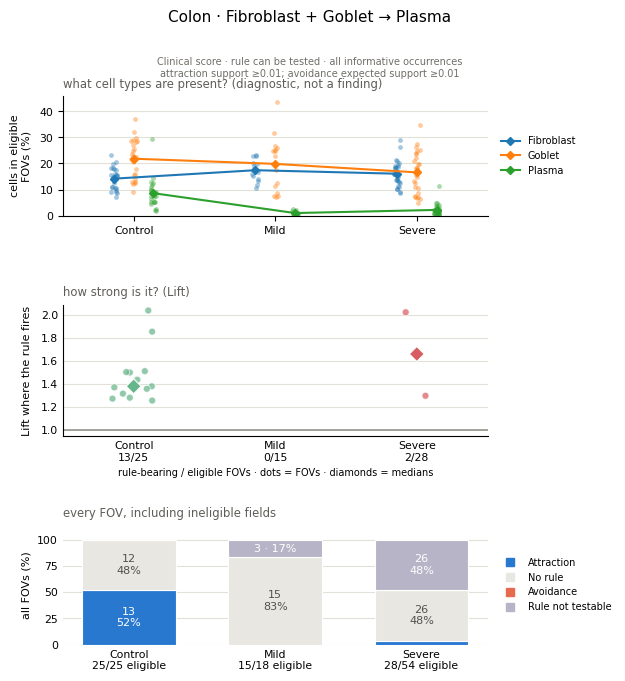

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_cae6b5640c_parents.pdf


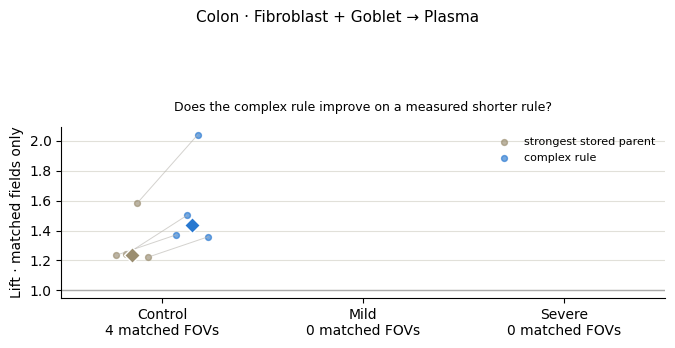

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,4,1.436309,1.237937,4


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_cae6b5640c_fovs_attraction_control.pdf


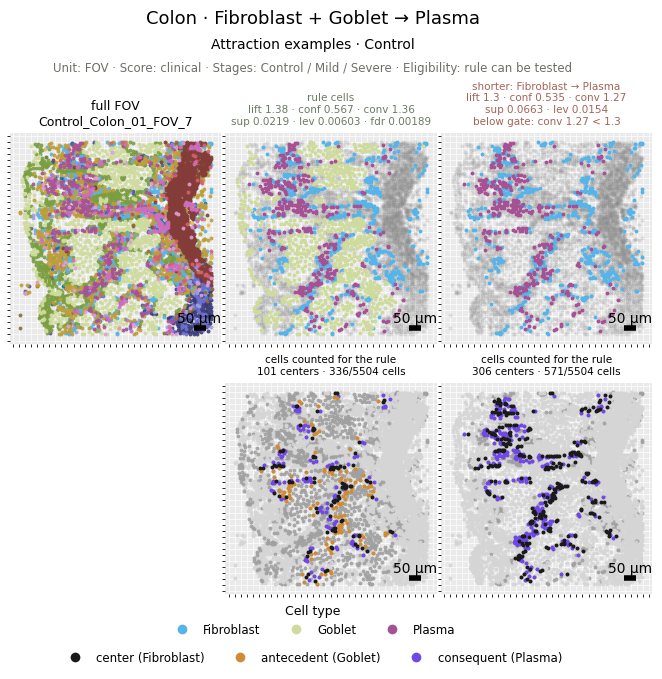

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_cae6b5640c_fovs_attraction_severe.pdf


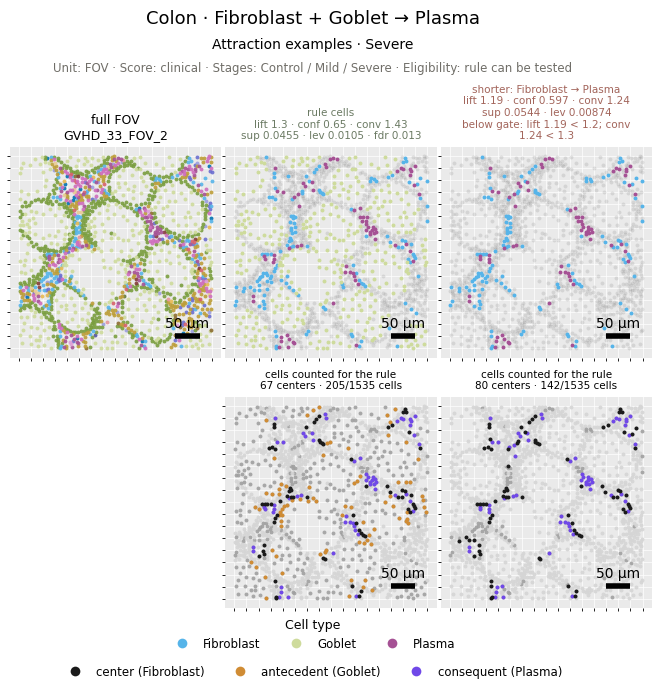

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Colon_cae6b5640c_fovs_no_rule.pdf


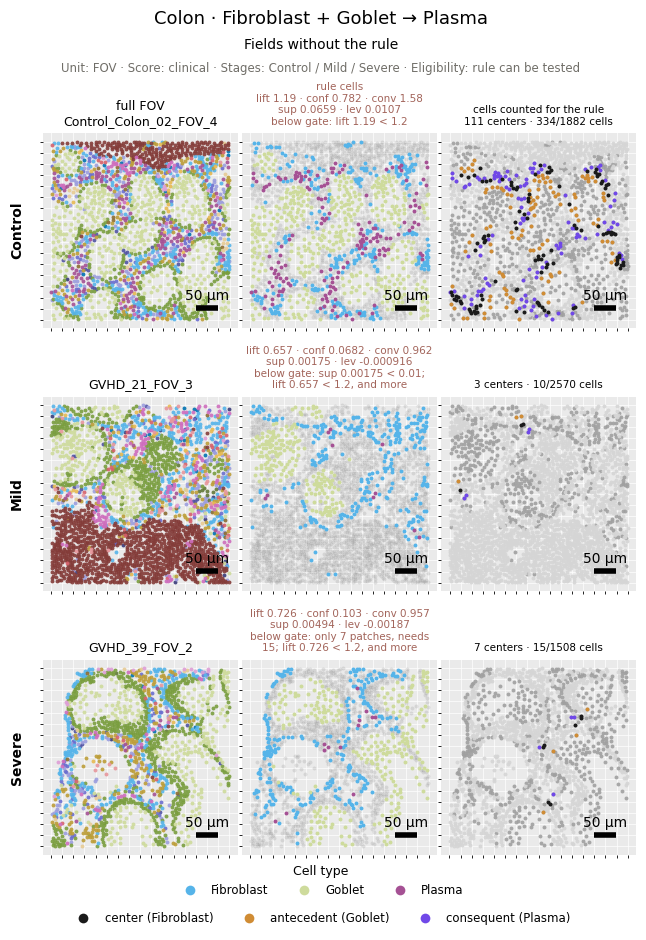

In [18]:
vis.show_selected(3, SPECS, analysis, rules, cells, metadata, "staging_clin", parents=True)

## Threshold check for the already ranked Paneth candidate

This follows the existing baseline selection at index 6. The strict support gate is a sensitivity check, not another selection screen.

**[6] Duodenum · CD4T + Goblet -> Plasma**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,8,51,170,6,22
1,All,avoids,0,51,170,0,22
2,Control,attracts,7,19,31,5,7
3,Control,avoids,0,19,31,0,7
4,Mild,attracts,1,29,98,1,13
5,Mild,avoids,0,29,98,0,13
6,Severe,attracts,0,3,41,0,2
7,Severe,avoids,0,3,41,0,2


No measured shorter rule for a prevalence comparison.
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Duodenum_b52effceb2_summary.pdf


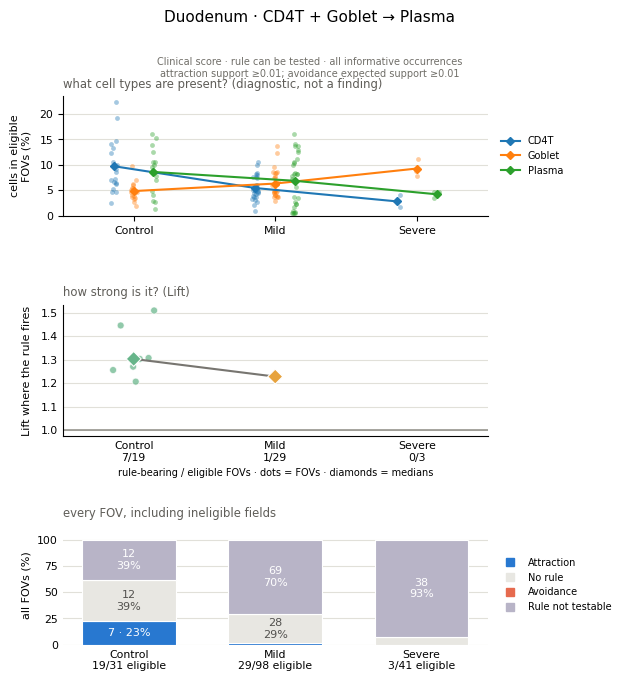

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Duodenum_b52effceb2_fovs_attraction.pdf


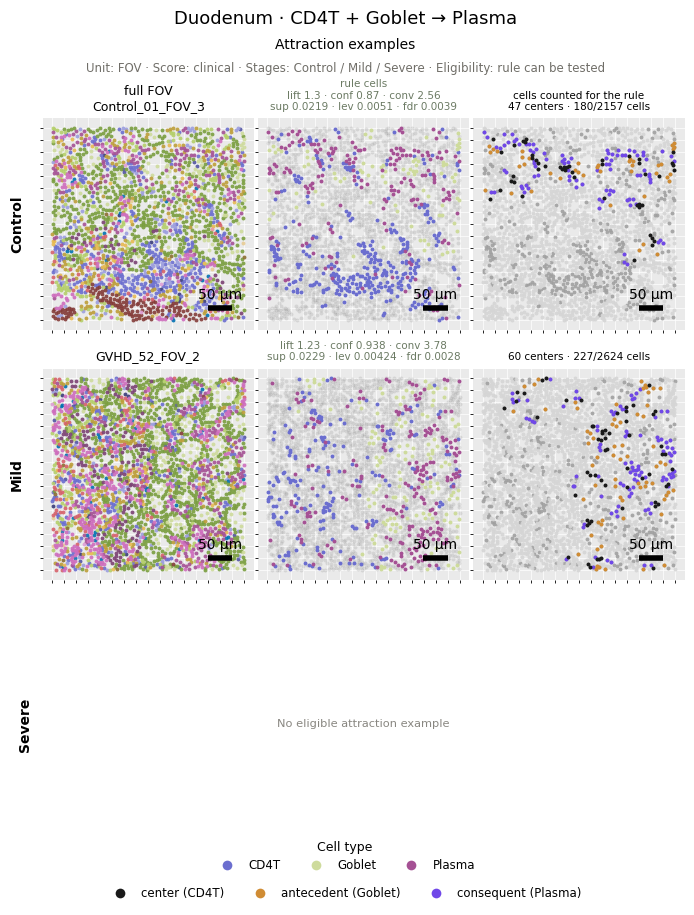

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\staging_clin_Duodenum_b52effceb2_fovs_no_rule.pdf


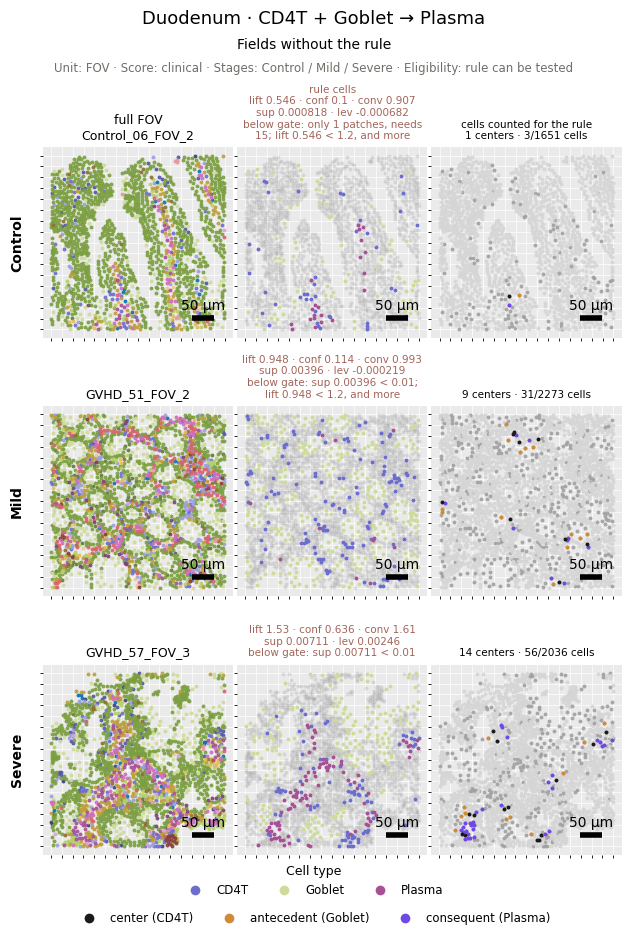

In [19]:
vis.show_selected(6, SPECS, analysis, rules, cells, metadata, "staging_clin", parents=False)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_001_Duodenum_b52effceb2_summary.pdf


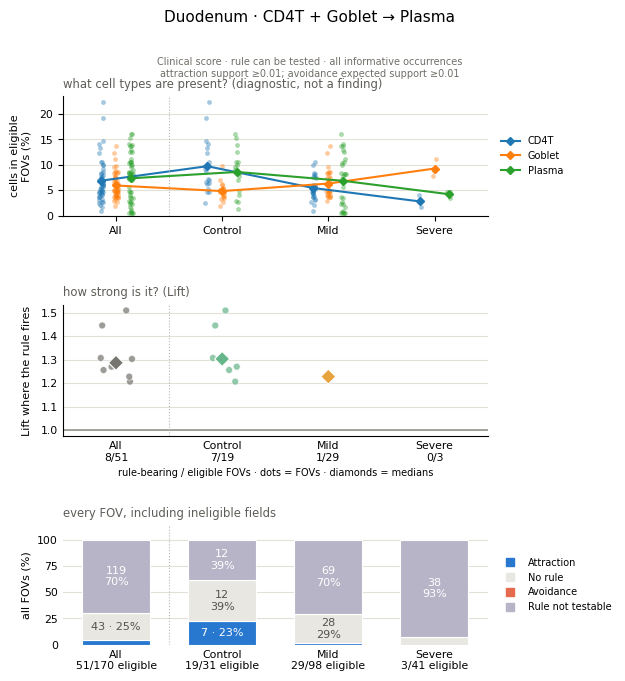

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\support_clin_003_Duodenum_b52effceb2_summary.pdf


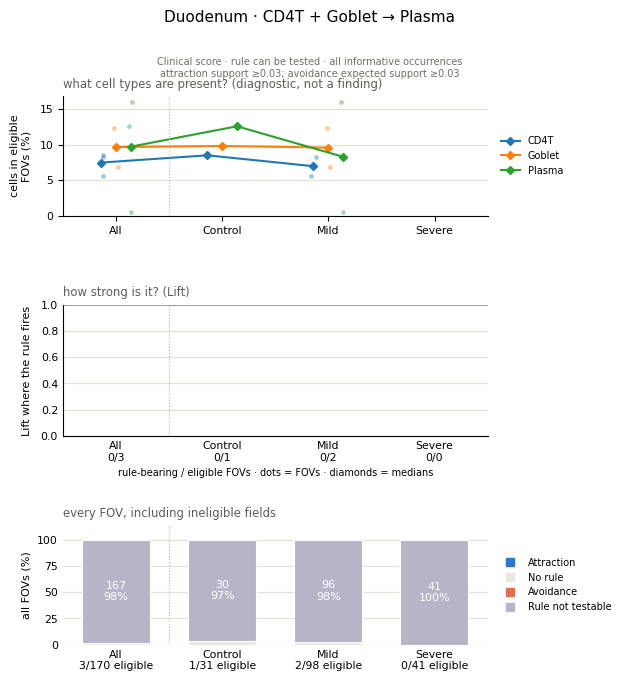

In [20]:
STRICT = replace(CONFIG, support=0.03, expected_support=0.03)
strict_analysis = ci.analyse(rules, cells, metadata, STRICT)
vis.show_threshold(6, SPECS, analysis, strict_analysis, metadata, prefix="support_clin", cells=cells)